In [93]:
# Download the data
import os
from dotenv import load_dotenv
from roboflow import Roboflow

load_dotenv()
api_key = os.environ.get("ROBOFLOW_API_KEY")

rf = Roboflow(api_key=api_key)
project = rf.workspace("cybertech-qde01").project("waste-classification-q75av-awlnx")
version = project.version(1)
dataset = version.download("multiclass")

loading Roboflow workspace...
loading Roboflow project...
loading Roboflow project...


In [94]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_path = dataset.location

class_names = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

def load_roboflow_split(split_name, batch_size=32, image_size=(224, 224)):
    folder_path = os.path.join(base_path, split_name)
    csv_path = os.path.join(folder_path, "_classes.csv")
        
    df = pd.read_csv(csv_path)
    
    # Normalize image data
    datagen = ImageDataGenerator(rescale=1./255)
    
    generator = datagen.flow_from_dataframe(
        dataframe=df,
        directory=folder_path,
        x_col="filename",
        y_col=class_names, 
        target_size=image_size,
        batch_size=batch_size,
        class_mode="raw", 
        shuffle=(split_name == "train") # only shuffle training data
    )
    
    return generator

train_gen = load_roboflow_split("train", batch_size=64)
valid_gen = load_roboflow_split("valid", batch_size=64)
test_gen = load_roboflow_split("test", batch_size=64)

Found 1767 validated image filenames.
Found 504 validated image filenames.
Found 253 validated image filenames.
Found 504 validated image filenames.
Found 253 validated image filenames.


In [95]:
import matplotlib.pyplot as plt
import numpy as np

def plot_image(images, labels=None, predictions=None, cmap=None, n_preds=10):
    show_label = True
    if labels is None:
        labels = images
        show_label = False

    show_prediction = True
    if predictions is None:
        predictions = images
        show_prediction = False

    for image, label, prediction in zip(images[:n_preds], labels, predictions):
        plt.xticks([])
        plt.yticks([])
        plt.imshow(image, cmap=cmap)

        label_text = ""

        if show_prediction:
          cls_pred = tf.math.argmax(prediction, axis=0)
          class_number = class_names[cls_pred] 

          label_text = f"\npredicted: {class_names[cls_pred]}, probability: {round(prediction[cls_pred], 2)}"

        if show_label:
            class_idx = np.argmax(label)
            plt.xlabel(f"{class_names[class_idx]}" + label_text)

        plt.show()

    if show_prediction:
      matches = tf.keras.metrics.sparse_categorical_accuracy(y_test[:10], test_preds[:10])
      print("accuracy: ", tf.reduce_mean(matches))

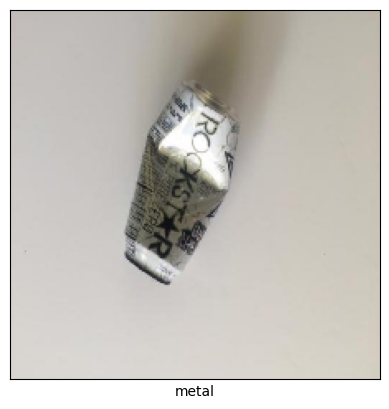

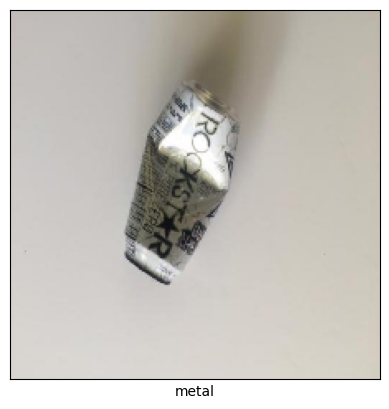

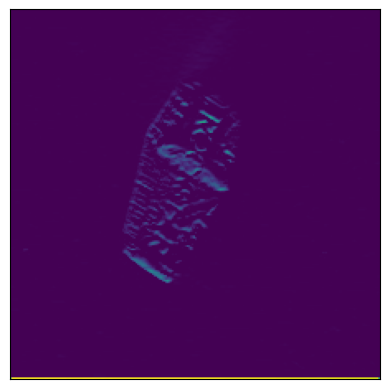

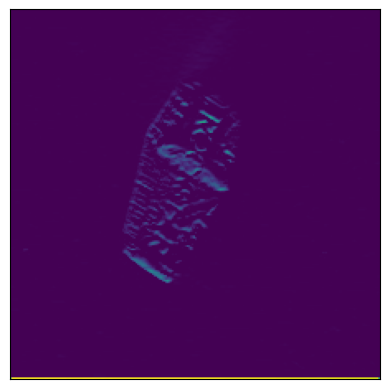

In [96]:

filters = 2
X_batch, y_batch = next(iter(train_gen))
sample_image, sample_label = X_batch[:1], y_batch[:1]
plot_image(sample_image, sample_label)

sample_convolution = tf.keras.layers.Conv2D(
    filters=filters,
    kernel_size=(3,3),
    activation='relu', # !!!!!
    padding="same",
    use_bias=False
)

sample_transformed = sample_convolution(sample_image)

sample_kernel = tf.constant([
    [1,      1,     1],
    [0,      0,     0],
    [-1,    -1,    -1]
])

# we create a 3D kernel for rgb, with copying the same kernel for every color channel
sample_kernel = tf.stack([sample_kernel, sample_kernel, sample_kernel], axis=-1)
sample_kernel_filters = tf.stack([sample_kernel, sample_kernel], axis=-1)

sample_convolution.set_weights([sample_kernel_filters])

sample_transformed = sample_convolution(sample_image)

plot_image(sample_image, sample_label)

for image in range(filters):
    # ... = :, :, :
    plot_image(sample_transformed[..., image])